In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("/Users/tunasavas/Desktop/football-beyond-xg/data.csv")

df.head()

,Unnamed: 0,group,rank,team,matches_played,wins,draws,losses,goals_scored,goals_against,goal_difference,points,expected_goal_scored,exp_goal_conceded,exp_goal_difference,exp_goal_difference_per_90
0,0,1,1,Netherlands,3,2,1,0,5,1,4,7,2.4,2.7,-0.3,-0.11
1,1,1,2,Senegal,3,2,0,1,5,4,1,6,3.8,2.5,1.3,0.43
2,2,1,3,Ecuador,3,1,1,1,4,3,1,4,3.7,2.6,1.2,0.39
3,3,1,4,Qatar,3,0,0,3,1,7,-6,0,1.4,3.5,-2.1,-0.71
4,4,2,1,England,3,2,1,0,9,2,7,7,5.2,2.3,2.9,0.97


In [2]:
print(df.columns)
print(df.shape)
df.describe()

Index(['Unnamed: 0', 'group', 'rank', 'team', 'matches_played', 'wins',
       'draws', 'losses', 'goals_scored', 'goals_against', 'goal_difference',
       'points', 'expected_goal_scored', 'exp_goal_conceded',
       'exp_goal_difference', 'exp_goal_difference_per_90'],
      dtype='object')
(32, 16)


,Unnamed: 0,group,rank,matches_played,wins,draws,losses,goals_scored,goals_against,goal_difference,points,expected_goal_scored,exp_goal_conceded,exp_goal_difference,exp_goal_difference_per_90
count,32.000000,32.000000,32.000000,32.0,32.000000,32.000000,32.000000,32.000000,32.00000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,15.500000,4.500000,2.500000,3.0,1.187500,0.625000,1.187500,3.750000,3.75000,0.000000,4.187500,3.850000,3.846875,0.006250,-0.000625
std,9.380832,2.327951,1.135924,0.0,0.692704,0.609071,0.780302,2.079082,2.44949,3.282407,1.990907,1.750944,1.883542,3.062461,1.023139
min,0.000000,1.000000,1.000000,3.0,0.000000,0.000000,0.000000,1.000000,1.00000,-8.000000,0.000000,1.400000,0.700000,-8.700000,-2.900000
25%,7.750000,2.750000,1.750000,3.0,1.000000,0.000000,1.000000,2.000000,2.00000,-2.000000,3.000000,2.700000,2.700000,-1.525000,-0.517500
50%,15.500000,4.500000,2.500000,3.0,1.000000,1.000000,1.000000,4.000000,3.00000,0.000000,4.000000,3.700000,3.500000,-0.050000,-0.020000
75%,23.250000,6.250000,3.250000,3.0,2.000000,1.000000,2.000000,5.000000,5.00000,2.000000,6.000000,4.450000,4.600000,1.225000,0.400000
max,31.000000,8.000000,4.000000,3.0,2.000000,2.000000,3.000000,9.000000,11.00000,7.000000,7.000000,10.100000,10.100000,6.700000,2.220000


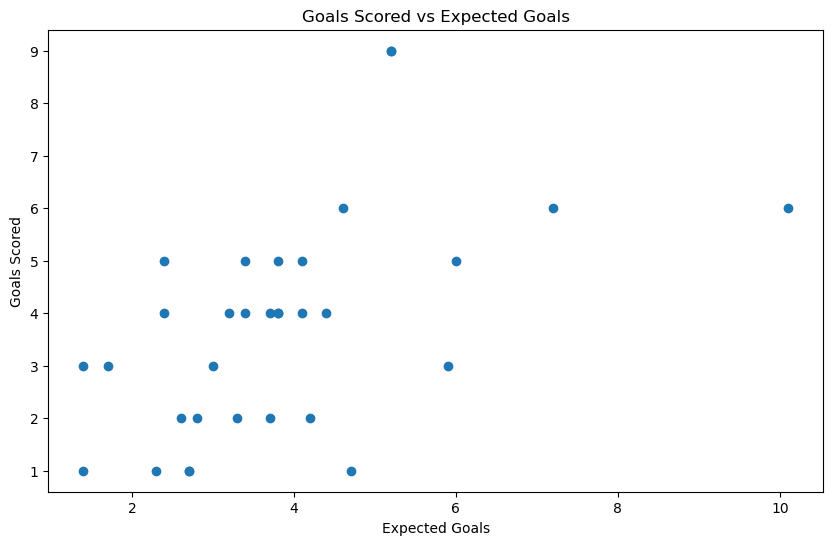

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(df["expected_goal_scored"], df["goals_scored"])
plt.xlabel("Expected Goals")
plt.ylabel("Goals Scored")
plt.title("Goals Scored vs Expected Goals")
plt.show()

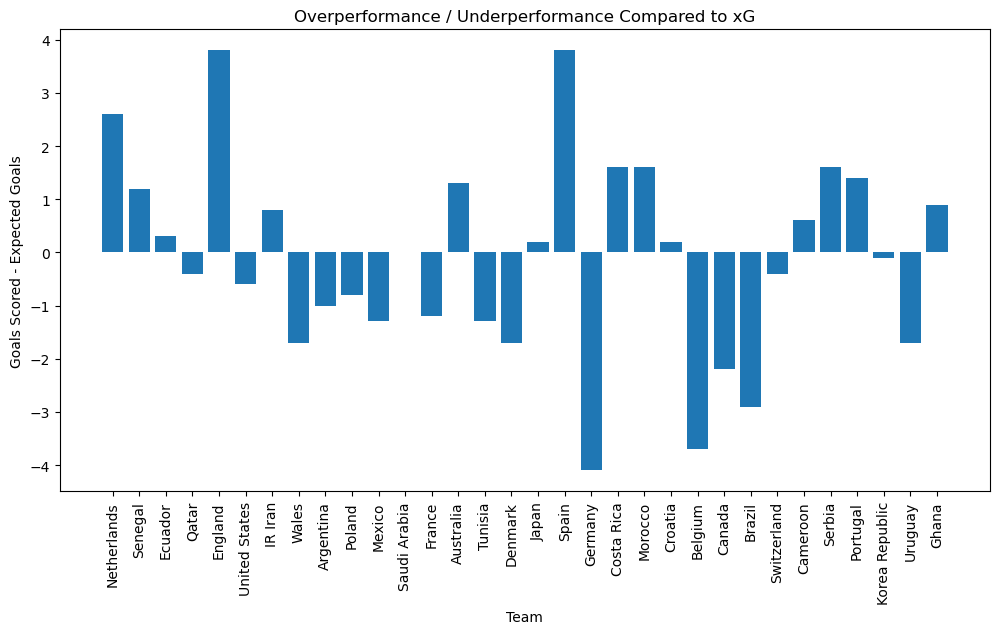

In [4]:
df["performance"] = df["goals_scored"] - df["expected_goal_scored"]

plt.figure(figsize=(12,6))
plt.bar(df["team"], df["performance"])
plt.xticks(rotation=90)
plt.xlabel("Team")
plt.ylabel("Goals Scored - Expected Goals")
plt.title("Overperformance / Underperformance Compared to xG")
plt.show()

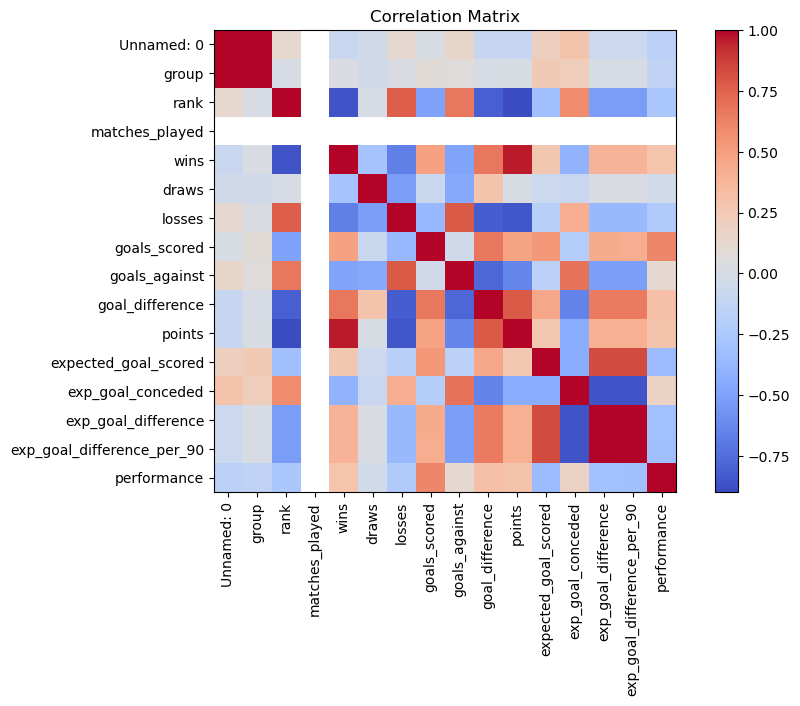

In [5]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))
plt.imshow(numeric_df.corr(), cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
plt.title("Correlation Matrix")
plt.show()

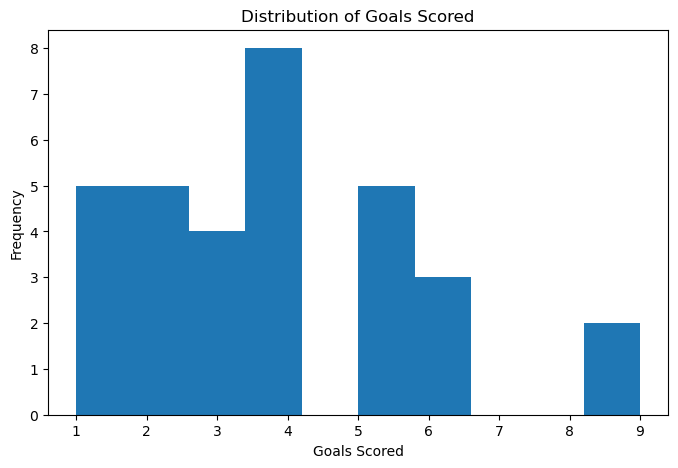

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["goals_scored"], bins=10)
plt.title("Distribution of Goals Scored")
plt.xlabel("Goals Scored")
plt.ylabel("Frequency")
plt.show()

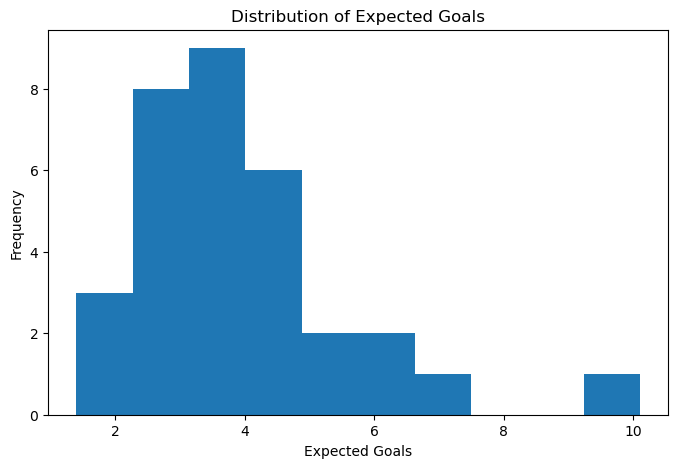

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["expected_goal_scored"], bins=10)
plt.title("Distribution of Expected Goals")
plt.xlabel("Expected Goals")
plt.ylabel("Frequency")
plt.show()

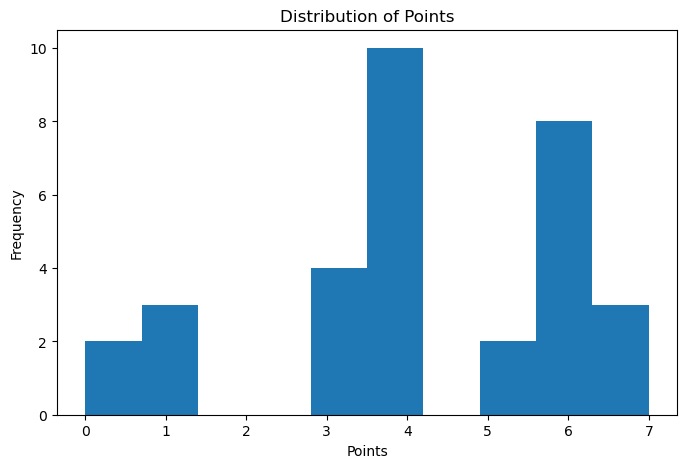

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["points"], bins=10)
plt.title("Distribution of Points")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()

## EDA Distribution Interpretation

The distribution plots show the basic structure of the dataset. Goals scored and expected goals are not evenly distributed among teams. Some teams scored and created much more than others, while many teams stayed around lower values.

The points distribution also shows that team success varies clearly across the tournament. This supports the idea that football performance cannot be explained by only one metric. xG is useful, but goals, points, and overall team performance should also be considered together.

In [9]:
df["overperform"] = (df["goals_scored"] > df["expected_goal_scored"]).astype(int)

df[["goals_scored", "expected_goal_scored", "overperform"]].head()

,goals_scored,expected_goal_scored,overperform
0,5,2.4,1
1,5,3.8,1
2,4,3.7,1
3,1,1.4,0
4,9,5.2,1


In [10]:
features = [
    "expected_goal_scored",
    "exp_goal_conceded",
    "exp_goal_difference",
    "points",
    "goal_difference",
    "wins"
]

X = df[features]
y = df["overperform"]

X.head()

,expected_goal_scored,exp_goal_conceded,exp_goal_difference,points,goal_difference,wins
0,2.4,2.7,-0.3,7,4,2
1,3.8,2.5,1.3,6,1,2
2,3.7,2.6,1.2,4,1,1
3,1.4,3.5,-2.1,0,-6,0
4,5.2,2.3,2.9,7,7,2


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (22, 6)
Test size: (10, 6)


In [12]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(confusion_matrix(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7
[[5 3]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      0.62      0.77         8
           1       0.40      1.00      0.57         2

    accuracy                           0.70        10
   macro avg       0.70      0.81      0.67        10
weighted avg       0.88      0.70      0.73        10



In [13]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print(confusion_matrix(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 0.6
[[4 4]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         8
           1       0.33      1.00      0.50         2

    accuracy                           0.60        10
   macro avg       0.67      0.75      0.58        10
weighted avg       0.87      0.60      0.63        10



In [14]:
forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, forest_pred))
print(confusion_matrix(y_test, forest_pred))
print(classification_report(y_test, forest_pred))

Random Forest Accuracy: 0.5
[[3 5]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      0.38      0.55         8
           1       0.29      1.00      0.44         2

    accuracy                           0.50        10
   macro avg       0.64      0.69      0.49        10
weighted avg       0.86      0.50      0.53        10



In [15]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred)
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.7
1,Decision Tree,0.6
2,Random Forest,0.5


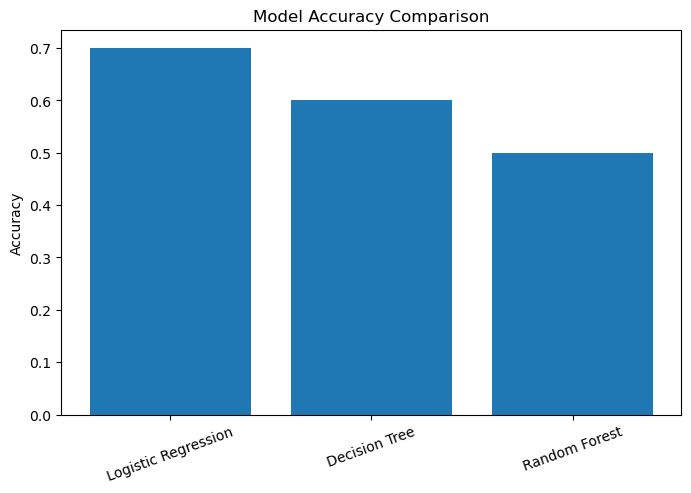

In [16]:
plt.figure(figsize=(8,5))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [17]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances

,Feature,Importance
0,expected_goal_scored,0.219759
1,exp_goal_conceded,0.180611
4,goal_difference,0.171884
3,points,0.170018
2,exp_goal_difference,0.158779
5,wins,0.098950


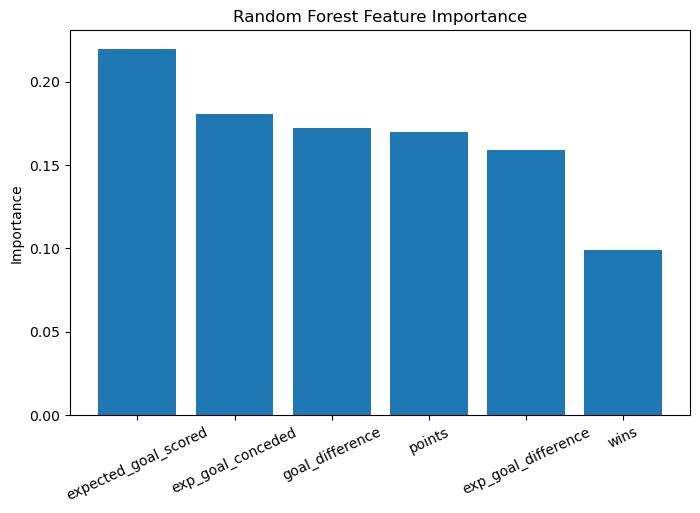

In [18]:
plt.figure(figsize=(8,5))
plt.bar(importances["Feature"], importances["Importance"])
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=25)
plt.show()

In [19]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, forest_pred))

print("\nModel Results Table:")
print(model_results)

print("\nShapes check:")
print("y_test:", len(y_test))
print("log_pred:", len(log_pred))
print("tree_pred:", len(tree_pred))
print("forest_pred:", len(forest_pred))

Logistic Regression Accuracy: 0.7
Decision Tree Accuracy: 0.6
Random Forest Accuracy: 0.5

Model Results Table:
                 Model  Accuracy
0  Logistic Regression       0.7
1        Decision Tree       0.6
2        Random Forest       0.5

Shapes check:
y_test: 10
log_pred: 10
tree_pred: 10
forest_pred: 10


## Machine Learning Results Interpretation

The machine learning models produced moderate accuracy results. Logistic Regression achieved the highest accuracy with 0.7, while Decision Tree achieved 0.6 and Random Forest achieved 0.5.

These results suggest that expected goals related features can provide useful information for predicting whether a team overperformed compared to its xG values.

Logistic Regression performed the best, which may indicate that the relationship between the selected features and overperformance is relatively linear. Decision Tree also produced reasonable results, while Random Forest showed lower performance on this small dataset.

One limitation of the project is the small dataset size, since the analysis only includes World Cup 2022 team statistics. Football is also highly unpredictable, and factors such as finishing quality, luck, defensive pressure, and match context can influence actual outcomes.

Overall, the models show that xG based statistics are useful indicators, but they are still not sufficient to fully explain football performance on their own.